# 注意力机制：从基础计算到 BERT 可视化

所有热力图采用统一样式：横轴为 Key（被关注词），纵轴为 Query（发起关注的词），颜色越深表示权重越高。

## 1. 环境与统一绘图函数

In [1]:
import os
import warnings

warnings.filterwarnings("ignore", message="The pynvml package is deprecated.*", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
sns.set_theme(style="white", context="talk")
plt.rcParams.update({"font.sans-serif": ["Microsoft YaHei", "SimHei", "DejaVu Sans"], "axes.unicode_minus": False, "figure.dpi": 120})

下面的函数统一处理 Tensor/NumPy 数组、标签校验、配色、数值标注和颜色条，后续不再重复编写绘图代码。

In [2]:
#把一个二维“注意力权重矩阵”画成热力图，让你直观看到每个 Query 词到底更关注哪些 Key 词。
def draw_attention_heatmap(
    matrix,
    x_labels,
    y_labels=None,
    title="注意力权重",
    cmap="YlGnBu",
    figsize=None,
    annot=True
):#annot是否在格子里显示数值
    # 转换为 numpy 数组
    matrix = matrix.detach().cpu().numpy() if isinstance(matrix, torch.Tensor) else np.asarray(matrix)
    y_labels = x_labels if y_labels is None else y_labels

    if matrix.ndim != 2:
        raise ValueError(f"热力图需要二维矩阵，当前形状为 {matrix.shape}")
    if matrix.shape != (len(y_labels), len(x_labels)):
        raise ValueError("矩阵形状必须与横纵轴标签数量一致")

    figsize = figsize or (max(7, len(x_labels) * 0.85), max(5.5, len(y_labels) * 0.7))
    fig, ax = plt.subplots(figsize=figsize, facecolor="#F7F9FC")

    sns.heatmap(
        matrix,
        ax=ax,
        annot=annot,
        fmt=".2f",
        cmap=cmap,
        vmin=0,
        xticklabels=x_labels,
        yticklabels=y_labels,
        linewidths=1.2,
        linecolor="#F7F9FC",
        square=True,
        cbar_kws={"label": "注意力权重", "shrink": 0.82, "pad": 0.02}
    )

    ax.set_title(title, fontsize=18, fontweight="bold", color="#17324D", pad=18)
    ax.set(xlabel="Key（被关注词）", ylabel="Query（发起关注的词）")
    ax.tick_params(axis="both", length=0, labelsize=11)

    plt.setp(
        ax.get_xticklabels(),
        rotation=35 if len(x_labels) > 6 else 0,
        ha="right" if len(x_labels) > 6 else "center",
        rotation_mode="anchor"
    )
    plt.setp(ax.get_yticklabels(), rotation=0, va="center")

    if annot:
        threshold = (matrix.min() + matrix.max()) / 2
        for label, value in zip(ax.texts, matrix.ravel()):
            label.set_color("white" if value >= threshold else "#17324D")
            label.set_fontweight("bold")
            label.set_fontsize(10)

    fig.tight_layout()
    plt.show()

## 2. 基础缩放点积注意力

核心公式：

`Attention(Q, K, V) = softmax(QKᵀ / √dₖ)V`

下面返回三个结果，便于观察中间过程：

- `scores`：缩放后的相似度分数
- `weights`：Softmax 后的注意力权重
- `output`：对 Value 加权求和后的输出

In [3]:
def self_attention(query, key, value):
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / (d_k ** 0.5)
    weights = F.softmax(scores, dim=-1)
    output = torch.matmul(weights, value)
    return output, weights, scores

### 准备 Q、K、V

In [4]:
query = torch.tensor([[[1.0, 0.0, 1.0, 0.0], [0.0, 1.0, 0.0, 1.0], [1.0, 1.0, 0.0, 0.0]]])
key = query.clone()
value = torch.tensor([[[1.0, 0.0, 0.0, 1.0], [0.0, 2.0, 0.0, 0.0], [1.0, 1.0, 1.0, 0.0]]])

print(f"Query / Key / Value 形状：{query.shape} / {key.shape} / {value.shape}")
print("Query：\n", query, "\n\nValue：\n", value)

Query / Key / Value 形状：torch.Size([1, 3, 4]) / torch.Size([1, 3, 4]) / torch.Size([1, 3, 4])
Query：
 tensor([[[1., 0., 1., 0.],
         [0., 1., 0., 1.],
         [1., 1., 0., 0.]]]) 

Value：
 tensor([[[1., 0., 0., 1.],
         [0., 2., 0., 0.],
         [1., 1., 1., 0.]]])


### 计算注意力

In [5]:
output, weights, scores = self_attention(query, key, value)
print("缩放后的相似度分数：\n", scores, "\n\n注意力权重：\n", weights, "\n\n注意力输出：\n", output)

缩放后的相似度分数：
 tensor([[[1.0000, 0.0000, 0.5000],
         [0.0000, 1.0000, 0.5000],
         [0.5000, 0.5000, 1.0000]]]) 

注意力权重：
 tensor([[[0.5065, 0.1863, 0.3072],
         [0.1863, 0.5065, 0.3072],
         [0.2741, 0.2741, 0.4519]]]) 

注意力输出：
 tensor([[[0.8137, 0.6798, 0.3072, 0.5065],
         [0.4935, 1.3202, 0.3072, 0.1863],
         [0.7259, 1.0000, 0.4519, 0.2741]]])


### 验证每行权重之和

In [6]:
print("每一行注意力权重之和：\n", weights.sum(dim=-1))

每一行注意力权重之和：
 tensor([[1., 1., 1.]])


### 查看第一个词对其他词的注意力

In [7]:
tokens = ["机器", "学习", "有趣"]
first_token_weights = weights[0, 0]
for token, weight in zip(tokens, first_token_weights): print(f"“{tokens[0]}”对“{token}”的注意力：{weight.item():.4f}")

“机器”对“机器”的注意力：0.5065
“机器”对“学习”的注意力：0.1863
“机器”对“有趣”的注意力：0.3072


### 可视化基础注意力矩阵

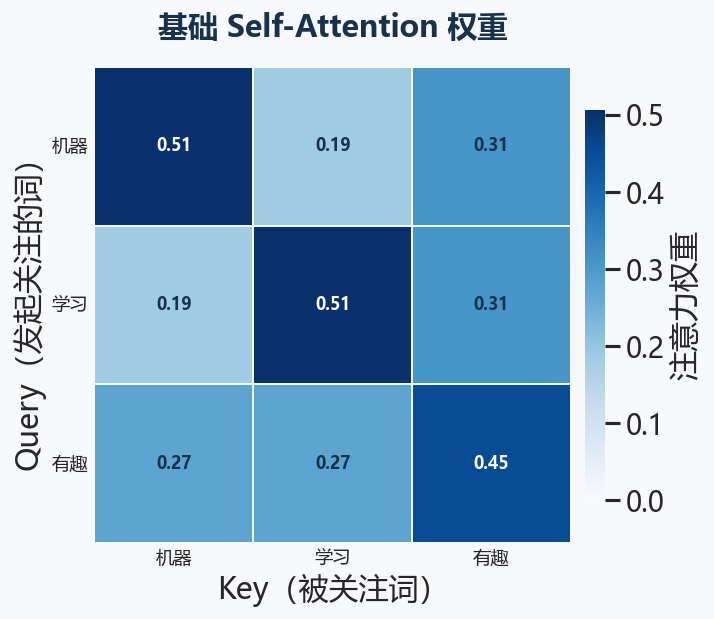

In [8]:
draw_attention_heatmap(weights[0], tokens, title="基础 Self-Attention 权重", cmap="Blues", figsize=(7, 5.5))

## 3. 多头注意力

原页面示例在拆分多头后没有正确交换维度。下面将张量转换为：

`[batch_size, num_heads, seq_len, d_k]`

再分别计算每个头的注意力。

In [9]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        if d_model % num_heads != 0: raise ValueError("d_model 必须能够被 num_heads 整除")
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        batch_size, seq_len, _ = x.shape
        return x.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

    def forward(self, query, key, value):
        Q = self.split_heads(self.W_q(query))
        K = self.split_heads(self.W_k(key))
        V = self.split_heads(self.W_v(value))
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
        weights = F.softmax(scores, dim=-1)
        head_outputs = torch.matmul(weights, V)
        combined_output = head_outputs.transpose(1, 2).contiguous().view(query.size(0), -1, self.d_model)
        return self.W_o(combined_output), weights, Q, K, V

### 创建测试输入

In [10]:
batch_size, seq_len, d_model, num_heads = 1, 4, 8, 2
x = torch.randn(batch_size, seq_len, d_model)
multi_head_attention = MultiHeadAttention(d_model, num_heads)
print(f"输入形状：{x.shape}；注意力头数量：{num_heads}；每个头的维度：{multi_head_attention.d_k}")

输入形状：torch.Size([1, 4, 8])；注意力头数量：2；每个头的维度：4


### 运行多头注意力

In [11]:
multi_output, multi_weights, Q, K, V = multi_head_attention(x, x, x)
print(f"Q / K / V 形状：{Q.shape} / {K.shape} / {V.shape}")
print(f"注意力权重形状：{multi_weights.shape}；最终输出形状：{multi_output.shape}")

Q / K / V 形状：torch.Size([1, 2, 4, 4]) / torch.Size([1, 2, 4, 4]) / torch.Size([1, 2, 4, 4])
注意力权重形状：torch.Size([1, 2, 4, 4])；最终输出形状：torch.Size([1, 4, 8])


### 查看每个注意力头

In [12]:
for head_index in range(num_heads): print(f"第 {head_index + 1} 个头每行权重之和：", multi_weights[0, head_index].sum(dim=-1))

第 1 个头每行权重之和： tensor([1., 1., 1., 1.], grad_fn=<SumBackward1>)
第 2 个头每行权重之和： tensor([1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>)


### 分别绘制每个注意力头

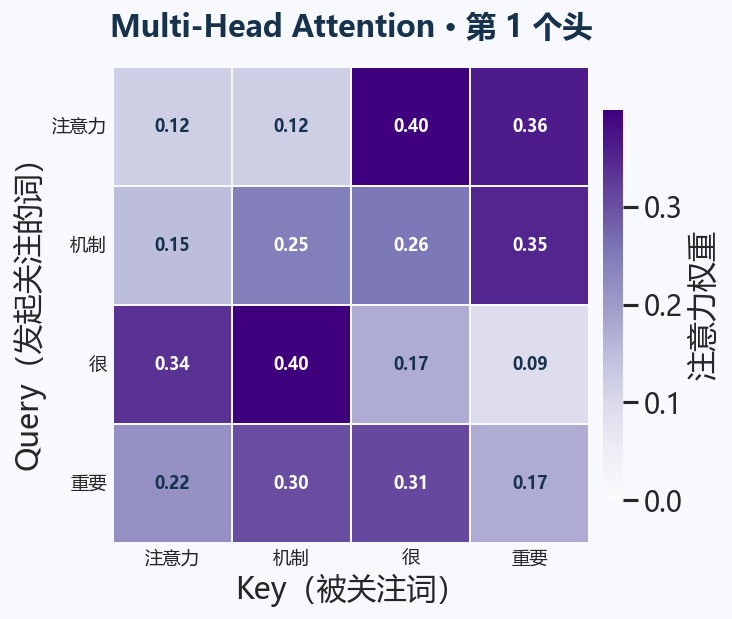

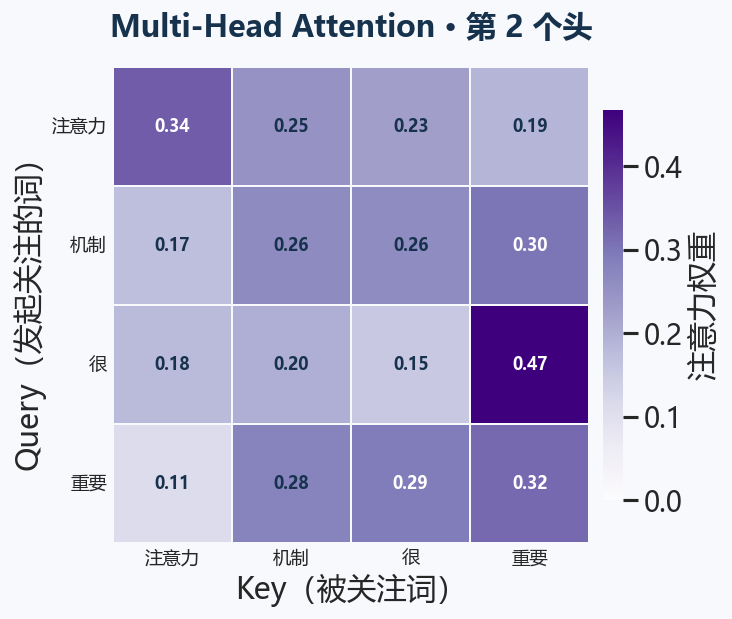

In [13]:
multi_tokens = ["注意力", "机制", "很", "重要"]
for head_index in range(num_heads):
    draw_attention_heatmap(multi_weights[0, head_index], multi_tokens, title=f"Multi-Head Attention · 第 {head_index + 1} 个头", cmap="Purples", figsize=(7, 5.5))

## 4. 简单注意力层

这个注意力层为编码器的每一个位置计算一个分数，再对全部编码器输出进行加权求和。

In [14]:
class SimpleAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, encoder_outputs):
        attention_scores = self.attention(encoder_outputs).squeeze(-1)
        attention_weights = F.softmax(attention_scores, dim=1)
        context_vector = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context_vector, attention_weights, attention_scores

### 准备编码器输出

In [15]:
encoder_outputs = torch.randn(1, 4, 6)
simple_attention = SimpleAttention(hidden_size=6)

print("编码器输出形状：", encoder_outputs.shape)
print("\n编码器输出：\n", encoder_outputs)

编码器输出形状： torch.Size([1, 4, 6])

编码器输出：
 tensor([[[ 0.4334, -0.7172,  1.0554, -1.4534,  0.4652,  0.3714],
         [-0.0047,  0.0795,  0.3273,  0.1292,  2.8520, -0.7436],
         [ 0.1954, -1.3350,  0.3945,  1.7060, -0.3071, -0.7155],
         [ 0.0762, -0.2127, -0.5663,  0.3989,  1.3695, -0.2519]]])


### 运行简单注意力

In [16]:
context_vector, simple_weights, simple_scores = simple_attention(encoder_outputs)

print("注意力原始分数：\n", simple_scores)
print("\n注意力权重：\n", simple_weights)
print("\n上下文向量：\n", context_vector)
print("\n上下文向量形状：", context_vector.shape)

注意力原始分数：
 tensor([[-0.1160,  0.3936,  0.1269,  0.5592]], grad_fn=<SqueezeBackward1>)

注意力权重：
 tensor([[0.1694, 0.2819, 0.2159, 0.3327]], grad_fn=<SoftmaxBackward0>)

上下文向量：
 tensor([[ 0.1396, -0.4581,  0.1678,  0.2914,  1.2722, -0.3851]],
       grad_fn=<SqueezeBackward1>)

上下文向量形状： torch.Size([1, 6])


### 逐个查看词语权重

In [17]:
sentence_tokens = ["人工智能", "正在", "改变", "世界"]

for token, weight in zip(sentence_tokens, simple_weights[0]): print(f"{token}：{weight.item():.4f}")
print("权重总和：", simple_weights[0].sum().item())

人工智能：0.1694
正在：0.2819
改变：0.2159
世界：0.3327
权重总和： 1.0


## 5. 跨序列注意力可视化

下面用模拟翻译注意力展示非方阵情形：横轴是英文源词，纵轴是法文目标词。这里继续复用统一热力图函数。

### 生成模拟翻译注意力

In [18]:
source_tokens = ["The", "cat", "sat", "on", "the", "mat"]
target_tokens = ["Le", "chat", "s'est", "assis", "sur", "le", "tapis"]
translation_attention = F.softmax(torch.randn(len(target_tokens), len(source_tokens)), dim=-1)

print("注意力矩阵形状：", translation_attention.shape)
print("每一行权重之和：", translation_attention.sum(dim=-1))

注意力矩阵形状： torch.Size([7, 6])
每一行权重之和： tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


### 绘制模拟翻译注意力

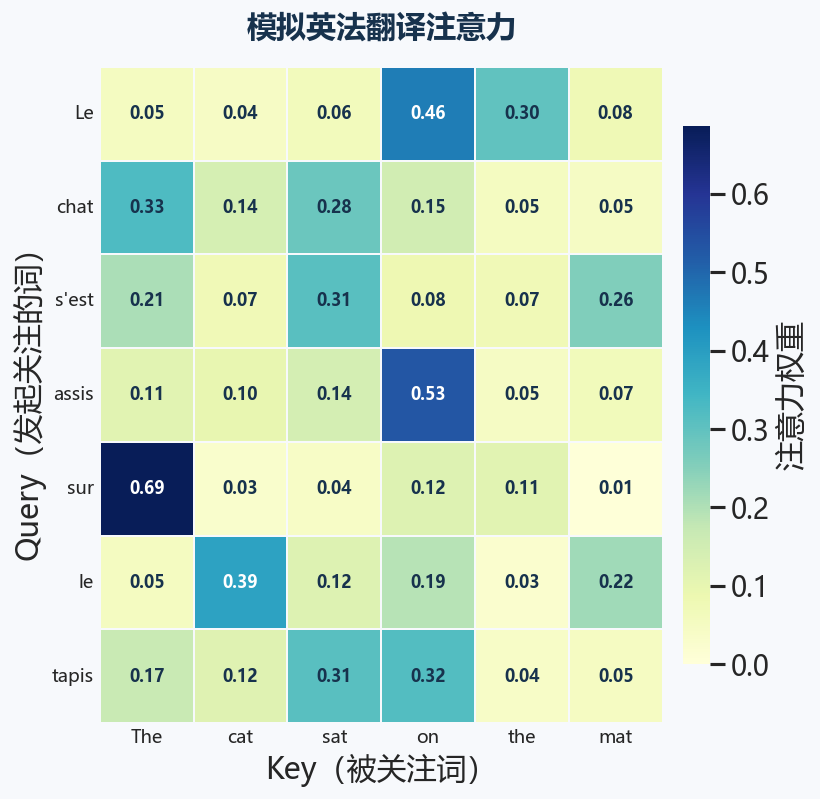

In [19]:
draw_attention_heatmap(translation_attention, source_tokens, target_tokens, title="模拟英法翻译注意力", cmap="YlGnBu", figsize=(9, 7))

## 6. 使用本地 BERT 获取真实注意力权重

这部分从 `data/hf_cache_bert_uncased` 加载本地英文 BERT。代码设置 `local_files_only=True`，运行时不会联网；目录中需要配置、词表和模型权重文件。

### 检查本地 BERT 文件

In [20]:
bert_path = r"D:\11\NLP\data\hf_cache_bert_uncased"
required_files = ["config.json", "tokenizer_config.json", "vocab.txt"]
weight_files = ["model.safetensors", "pytorch_model.bin"]

print("模型文件夹是否存在：", os.path.isdir(bert_path))
for file_name in required_files: print(f"{file_name}：", "存在" if os.path.isfile(os.path.join(bert_path, file_name)) else "缺失")
print("模型权重：", "存在" if any(os.path.isfile(os.path.join(bert_path, name)) for name in weight_files) else "缺失")

模型文件夹是否存在： True
config.json： 存在
tokenizer_config.json： 存在
vocab.txt： 存在
模型权重： 存在


### 从本地加载 BERT

In [21]:
from transformers import BertModel, BertTokenizer

tokenizer = BertTokenizer.from_pretrained(bert_path, local_files_only=True)
bert_model = BertModel.from_pretrained(bert_path, local_files_only=True, attn_implementation="eager")
bert_model.eval()
print(f"BERT 加载成功：{bert_model.config.num_hidden_layers} 层，{bert_model.config.num_attention_heads} 个注意力头，隐藏层维度 {bert_model.config.hidden_size}")

BERT 加载成功：12 层，12 个注意力头，隐藏层维度 768


### 对英文句子分词

In [22]:
text = "The cat is sitting on the mat."
inputs = tokenizer(text, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

print("原始句子：", text)
print("Token编号：", inputs["input_ids"])
print("分词结果：", tokens)

原始句子： The cat is sitting on the mat.
Token编号： tensor([[  101,  1996,  4937,  2003,  3564,  2006,  1996, 13523,  1012,   102]])
分词结果： ['[CLS]', 'the', 'cat', 'is', 'sitting', 'on', 'the', 'mat', '.', '[SEP]']


### 运行 BERT 并获取全部注意力层

In [23]:
with torch.no_grad(): bert_outputs = bert_model(**inputs, output_attentions=True)
bert_attentions = torch.stack(bert_outputs.attentions)
print(f"注意力张量形状：[层, 批次, 头, Query, Key] = {tuple(bert_attentions.shape)}")

注意力张量形状：[层, 批次, 头, Query, Key] = (12, 1, 12, 10, 10)


### 查看最后一层第一个注意力头

In [24]:
layer_index, head_index = bert_attentions.size(0) - 1, 0
bert_attention_matrix = bert_attentions[layer_index, 0, head_index]
print(f"选择第 {layer_index + 1} 层、第 {head_index + 1} 个头；矩阵形状：{tuple(bert_attention_matrix.shape)}")

选择第 12 层、第 1 个头；矩阵形状：(10, 10)


### 查看 cat 对其他 Token 的注意力

In [25]:
query_token = "cat"
query_index = tokens.index(query_token)
query_weights = bert_attention_matrix[query_index]
for token, weight in zip(tokens, query_weights): print(f"{query_token} → {token}：{weight.item():.4f}")
print("权重总和：", query_weights.sum().item())

cat → [CLS]：0.0078
cat → the：0.0043
cat → cat：0.0061
cat → is：0.0038
cat → sitting：0.0008
cat → on：0.0005
cat → the：0.0010
cat → mat：0.0007
cat → .：0.5480
cat → [SEP]：0.4269
权重总和： 0.9999998807907104


### 可视化 BERT 的一个注意力头

单个注意力头通常会形成较有针对性的关注模式，适合观察特定 Token 之间的关系。

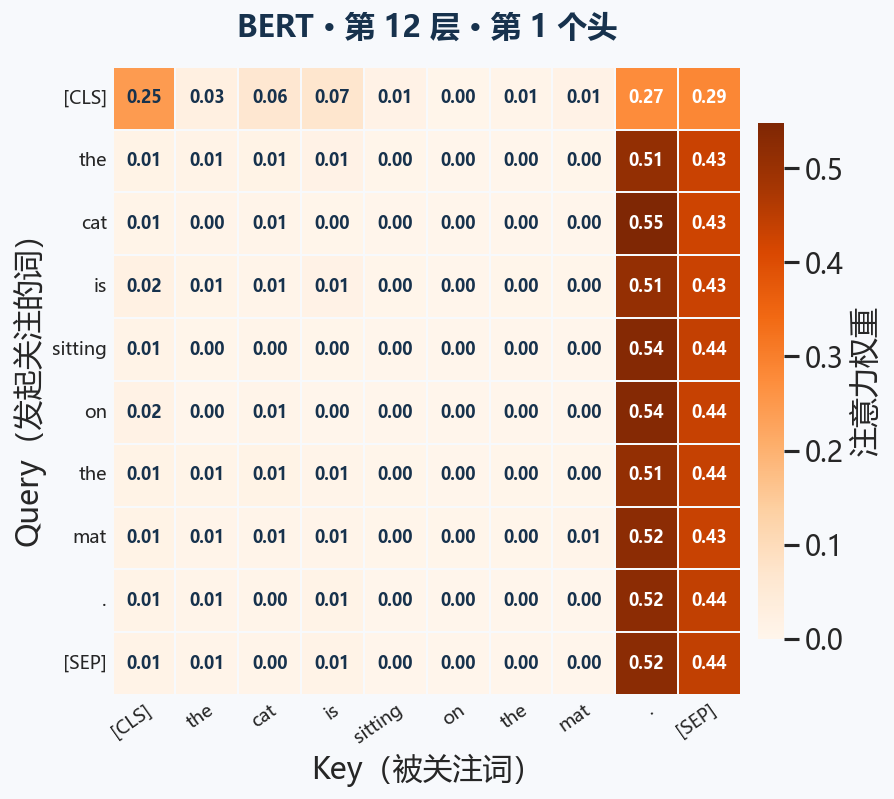

In [26]:
draw_attention_heatmap(bert_attention_matrix, tokens, title=f"BERT · 第 {layer_index + 1} 层 · 第 {head_index + 1} 个头", cmap="Oranges")

### 计算最后一层所有注意力头的平均值

In [27]:
average_attention = bert_attentions[-1, 0].mean(dim=0)
print("平均注意力矩阵形状：", average_attention.shape)
print("每一行权重之和：", average_attention.sum(dim=-1))

平均注意力矩阵形状： torch.Size([10, 10])
每一行权重之和： tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000])


### 可视化最后一层平均注意力

对最后一层的全部注意力头取平均，可弱化单个头的偶然波动，更适合作为汇报中的整体观察图。

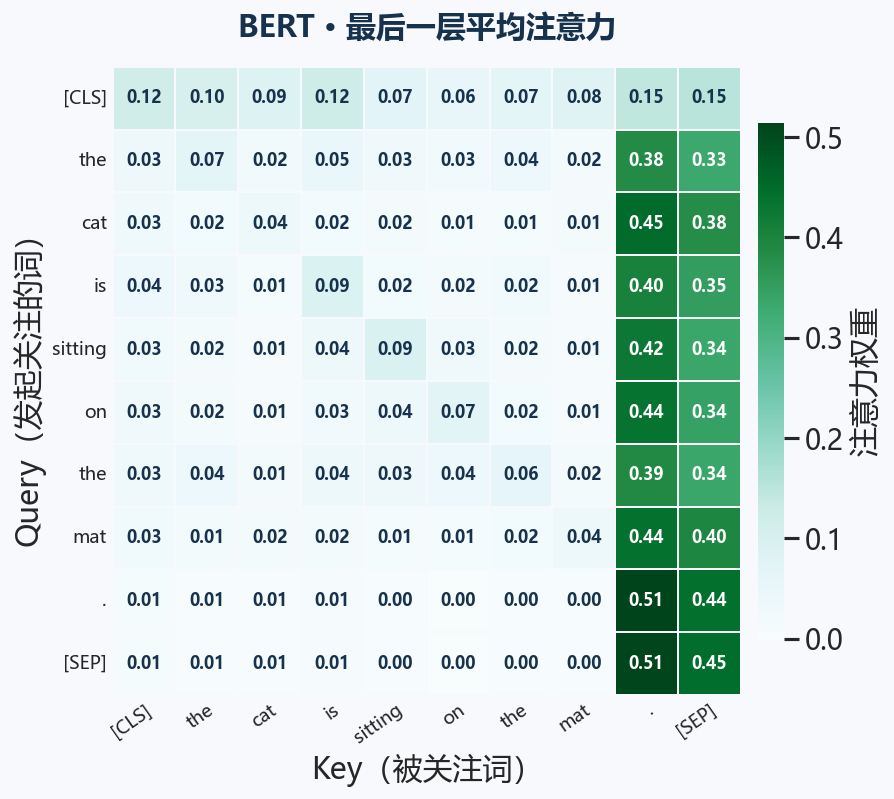

In [28]:
draw_attention_heatmap(average_attention, tokens, title="BERT · 最后一层平均注意力", cmap="BuGn")